# Imports

In [1]:
import os

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import roc_curve, confusion_matrix, auc
from tqdm import tqdm

from dataset import ASVspoof2019LADataset
from classifiers import SAPClassifier, SPClassifier, MPClassifier
from pred_single_file import predict_file
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

c:\Users\User\anaconda3\envs\ml_env_2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


def set_seed(seed: int = 42):
    # 1. Python random
    random.seed(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU)
    torch.manual_seed(seed)

    # 4. PyTorch (GPU)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 5. Ensure deterministic behavior (IMPORTANT)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 6. For extra reproducibility (optional but recommended)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed set to {seed}")

In [3]:
set_seed(42)

Seed set to 42


# Config

In [4]:
CONFIG = {
    # Paths
    "base_dir": "../augmented",
    "checkpoint_dir": "checkpoints",
    "checkpoint_name": "best_model_SAP_v3.pt",
    "model": SAPClassifier,
    
    # Training
    "batch_size": 16,
    "max_epochs": 100,
    "patience": 4,
    # Optimiser
    "lr_classifier": 2e-4,
    "lr_encoder":    1e-6,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "max_grad_norm": 0.5,
    
    # Loss
    "class_weights": [1.0, 1.0],
    
    # Inference
    "num_workers": 0,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Training on: cuda
GPU Name: NVIDIA GeForce RTX 5080


# Helper Functions

In [5]:
def compute_eer(labels, scores):
    """Computes the Equal Error Rate."""
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return fpr, tpr, idx, (fpr[idx] + fnr[idx]) / 2

def compute_metrics(labels, scores, preds):
    _, _, eer_idx, eer = compute_eer(labels, scores)
    return {
        "eer":       eer,
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall":    recall_score(labels, preds, average="weighted"),
    }

def run_inference(model, loader, device, loss_fn=None):
    """Runs inference and returns (labels, scores, preds) as numpy arrays."""
    model.eval()
    all_labels, all_scores, all_preds = [], [], []
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)

            with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                logits = model(input_values)
                if loss_fn is not None:
                    total_loss += loss_fn(logits, labels).item()

            probs = torch.softmax(logits.float(), dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader) if loss_fn is not None else None
    return np.array(all_labels), np.array(all_scores), np.array(all_preds), avg_loss

def plot_results(labels, scores, preds):
    """Plots ROC curve and confusion matrix side-by-side."""
    metrics = compute_metrics(labels, scores, preds)
    fpr, tpr, eer_idx, eer = compute_eer(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n--- Final Evaluation Results ---")
    print(f"EER:       {metrics['eer']       * 100:.2f}%")
    print(f"Accuracy:  {metrics['accuracy']  * 100:.2f}%")
    print(f"F1:        {metrics['f1']              :.4f}")
    print(f"Precision: {metrics['precision']       :.4f}")
    print(f"Recall:    {metrics['recall']          :.4f}")
    print(f"AUC:       {roc_auc                    :.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ROC Curve
    ax1.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    ax1.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    ax1.plot(fpr[eer_idx], tpr[eer_idx], "ro", markersize=8, label=f"EER ({eer*100:.2f}%)")
    ax1.set(xlim=[0, 1], ylim=[0, 1.05],
            xlabel="False Positive Rate (Spoof accepted as Real)",
            ylabel="True Positive Rate (Spoof correctly detected)",
            title="Receiver Operating Characteristic (ROC)")
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2,
                xticklabels=["Bonafide (0)", "Spoof (1)"],
                yticklabels=["Bonafide (0)", "Spoof (1)"])
    ax2.set(xlabel="Predicted Label", ylabel="True Label", title="Confusion Matrix")

    plt.tight_layout()
    plt.show()

In [6]:
from clearml import Task

task = Task.init(
    project_name="FilterPass",
    task_name="model-SAP-",
    task_type=Task.TaskTypes.training,
)

ClearML Task: created new task id=a863e1908b6a4d728b100ce61f82fd79
ClearML results page: https://app.clear.ml/projects/def022212af34cc6b7b7f5d5a035e1cc/experiments/a863e1908b6a4d728b100ce61f82fd79/output/log


ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [ ]:
task.close()

# Data, Model & Optimiser Setup

In [6]:
# Datasets & DataLoaders
train_dataset = ASVspoof2019LADataset(
    base_dir=CONFIG["base_dir"],
    split="train",
)

dev_dataset = ASVspoof2019LADataset(
    base_dir="../LA",
    split="dev",
)

# eval_dataset = ASVspoof2019LADataset(
#     base_dir=CONFIG["base_dir"],
#     split="eval",
#     use_vad=False,       # set True to filter silence
#     overlap_pct=0,       # set 25 or 50 for sliding window augmentation
# )


# train_dataset = ASVspoof2019LADataset(CONFIG["base_dir"], split="train")
# dev_dataset   = ASVspoof2019LADataset(CONFIG["base_dir"], split="dev")
# eval_dataset  = ASVspoof2019LADataset(CONFIG["base_dir"], split="eval")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
# eval_loader  = DataLoader(eval_dataset,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

Reading folder: ../augmented\train/flac
Reading folder: ../LA\ASVspoof2019_LA_dev/flac


In [7]:
# Model
model = CONFIG["model"]().to(device)

# Optimiser with differential learning rates
optimizer = torch.optim.AdamW([
    {"params": model.encoder.parameters(),    "lr": CONFIG["lr_encoder"]},
    {"params": model.classifier.parameters(), "lr": CONFIG["lr_classifier"]},
], weight_decay=CONFIG["weight_decay"])

# Scheduler
total_steps = len(train_loader) * CONFIG["max_epochs"]
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]),
    num_training_steps=total_steps,
)

# Loss & mixed-precision scaler
class_weights = torch.tensor(CONFIG["class_weights"]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
scaler  = torch.amp.GradScaler("cuda")

Initialising Self Attention Pooling Classfier


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 45256.87it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Training Loop

Evaluating: 100%|██████████| 3469/3469 [01:29<00:00, 38.66it/s]


Epoch 1 | Avg Loss: 0.6558 | Train Acc: 62.92% | Val Acc: 44.89% | Dev EER: 25.61%
  ⭐ New best EER — model saved.


Evaluating: 100%|██████████| 3469/3469 [01:30<00:00, 38.49it/s]


Epoch 2 | Avg Loss: 0.5416 | Train Acc: 72.42% | Val Acc: 52.31% | Dev EER: 22.38%
  ⭐ New best EER — model saved.


Evaluating: 100%|██████████| 3469/3469 [01:29<00:00, 38.77it/s]


...

Epoch 10 | Avg Loss: 0.4583 | Train Acc: 77.56% | Val Acc: 54.62% | Dev EER: 21.00%
  No improvement. Patience: 2/4


Evaluating: 100%|██████████| 3469/3469 [01:28<00:00, 39.02it/s]


Epoch 11 | Avg Loss: 0.4598 | Train Acc: 77.45% | Val Acc: 54.60% | Dev EER: 21.00%
  No improvement. Patience: 3/4


Evaluating: 100%|██████████| 3469/3469 [01:28<00:00, 39.01it/s]


Epoch 12 | Avg Loss: 0.4611 | Train Acc: 77.57% | Val Acc: 54.61% | Dev EER: 20.97%
  No improvement. Patience: 4/4
  🛑 Early stopping at epoch 12.


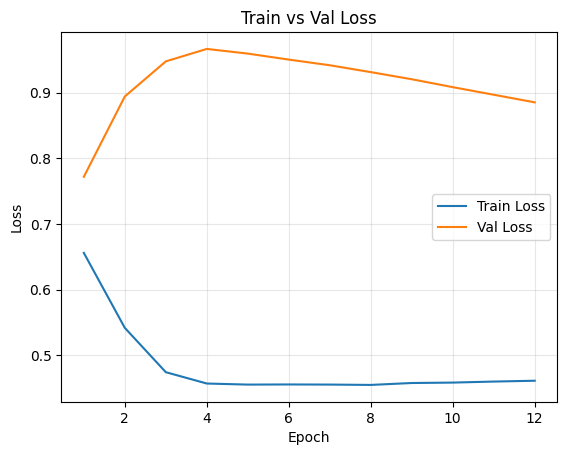

In [8]:
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], CONFIG["checkpoint_name"])

best_eer = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_eer": []}

for epoch in range(CONFIG["max_epochs"]):
    model.train()
    total_loss = 0
    correct, total = 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['max_epochs']}")
    for batch in pbar:
        input_values = batch["input_values"].to(device)
        labels       = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            logits = model(input_values)
            loss   = loss_fn(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total
    history["train_acc"].append(train_acc)

    labels_dev, scores_dev, preds_dev, val_loss = run_inference(model, dev_loader, device, loss_fn=loss_fn)
    history["train_loss"].append(avg_loss)
    history["val_loss"].append(val_loss)
    dev_eer = compute_eer(labels_dev, scores_dev)[3]
    val_acc = accuracy_score(labels_dev, preds_dev)
    history["val_acc"].append(val_acc)
    history["val_eer"].append(dev_eer)

    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Dev EER: {dev_eer*100:.2f}%")

    if dev_eer < best_eer:
        best_eer = dev_eer
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  ⭐ New best EER — model saved.")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{CONFIG['patience']}")
        if patience_counter >= CONFIG["patience"]:
            print(f"  🛑 Early stopping at epoch {epoch+1}.")
            break

# --- Plot training history ---
epochs = range(1, len(history["train_loss"]) + 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Train vs Val Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Evaluation on Eval Set

In [9]:
eval_dataset = ASVspoof2019LADataset(
    base_dir=CONFIG["base_dir"],
    split="eval",
    use_vad=False,       # set True to filter silence
    overlap_pct=0,       # set 25 or 50 for sliding window augmentation
)
eval_loader  = DataLoader(eval_dataset,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

FileNotFoundError: [Errno 2] No such file or directory: '../augmented\\ASVspoof2019.LA.cm.eval.trl.txt'

Loading checkpoint: checkpoints\best_model_SAP.pt
Initialising Self Attention Pooling Classfier


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 52769.55it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Evaluating: 100%|██████████| 29888/29888 [09:58<00:00, 49.97it/s]



--- Final Evaluation Results ---
EER:       26.27%
Accuracy:  82.11%
F1:        0.8352
Precision: 0.8536
Recall:    0.8211
AUC:       0.7479


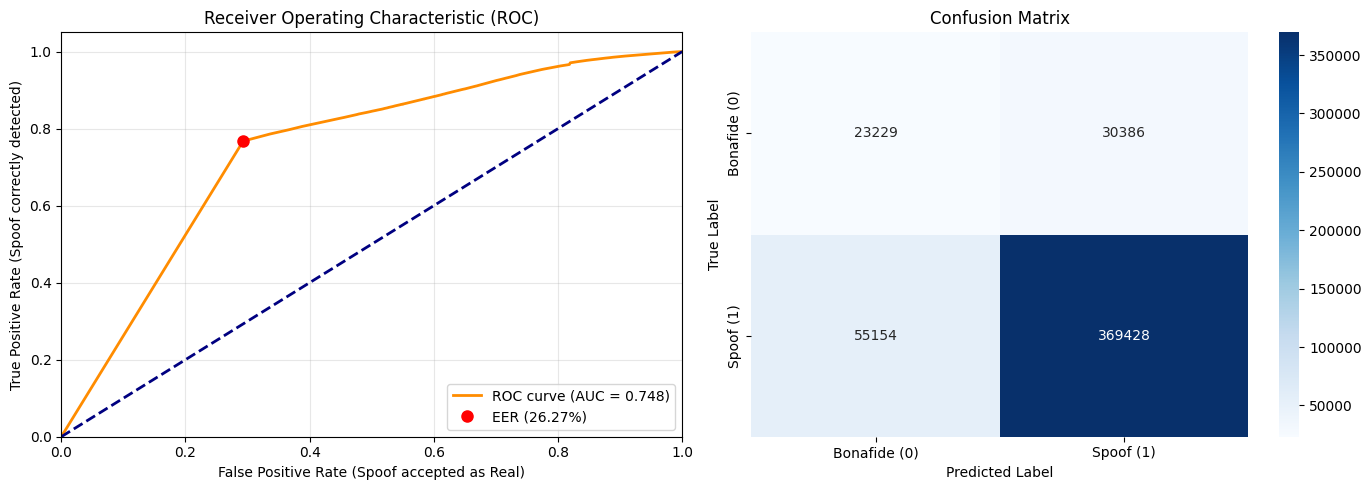

In [7]:
checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], CONFIG["checkpoint_name"])

print(f"Loading checkpoint: {checkpoint_path}")
model = CONFIG["model"]().to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

labels, scores, preds, _ = run_inference(model, eval_loader, device)
plot_results(labels, scores, preds)